# Sífilis em Ilhéus e Itabuna - análise temporal e comparativa

Este notebook compara as séries temporais das duas cidades e usa a Bahia como referência de contexto.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def encontrar_projeto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "Dados").exists() and (candidato / "Sifilis").exists():
            return candidato
        if (candidato / "DataSUS" / "Dados").exists():
            return candidato / "DataSUS"
    raise FileNotFoundError("Não foi possível localizar a pasta DataSUS.")

PROJECT_DIR = encontrar_projeto()
SIFILIS_DIR = PROJECT_DIR / "Sifilis"
DATA_DIR = PROJECT_DIR / "Dados"
OUTPUT_DIR = SIFILIS_DIR / "dados_processados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SIFILIS_DIR) not in sys.path:
    sys.path.insert(0, str(SIFILIS_DIR))

from sifilis_utils import (
    ANOS_ESPERADOS,
    CODIGOS_CIDADES,
    TIPOS_SIFILIS,
    carregar_agregados_demograficos,
    carregar_agregados_especificos,
    carregar_agregados_qualidade,
    carregar_agregados_temporais,
    carregar_base_cidades,
    caminho_artefato,
    exigir_cache_processado,
    exibir_markdown,
    formatar_inteiro,
    formatar_percentual,
    ler_tabela,
    salvar_figura,
    verificar_cache_processado,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

exigir_cache_processado(OUTPUT_DIR)

temporais = carregar_agregados_temporais(OUTPUT_DIR)
cidades_ano = temporais["sifilis_cidades_ano"]
cidades_ano_completo = temporais["sifilis_cidades_ano_completo"]
cidades_mes = temporais["sifilis_cidades_mes"]
bahia_ano = temporais["sifilis_bahia_ano"]
bahia_mes = temporais["sifilis_bahia_mes"]
participacao_ano = temporais["sifilis_representatividade_bahia_tipo"]
representatividade = temporais["sifilis_representatividade_bahia"]
taxa_total = temporais["sifilis_taxa_100_mil_total"]
taxa_tipo = temporais["sifilis_taxa_100_mil_por_tipo"]
comparacao_2024 = ler_tabela("sifilis_comparacao_2024", pasta_saida=OUTPUT_DIR)
origens_atendimento = ler_tabela("sifilis_municipios_residencia_atendidos", pasta_saida=OUTPUT_DIR, dtype={"codigo_residencia_sinan6": "string"})
municipios = ler_tabela("ibge_municipios_bahia", pasta_saida=OUTPUT_DIR, dtype={"codigo_sinan6": "string", "codigo_ibge7": "string"})
geojson_path = caminho_artefato("ibge_malha_bahia_municipios", OUTPUT_DIR)

In [2]:
cidades_mes["periodo_data"] = pd.to_datetime(cidades_mes["periodo_notificacao"].astype(str) + "-01", errors="coerce")
bahia_mes["periodo_data"] = pd.to_datetime(bahia_mes["periodo_notificacao"].astype(str) + "-01", errors="coerce")

## Série anual por cidade

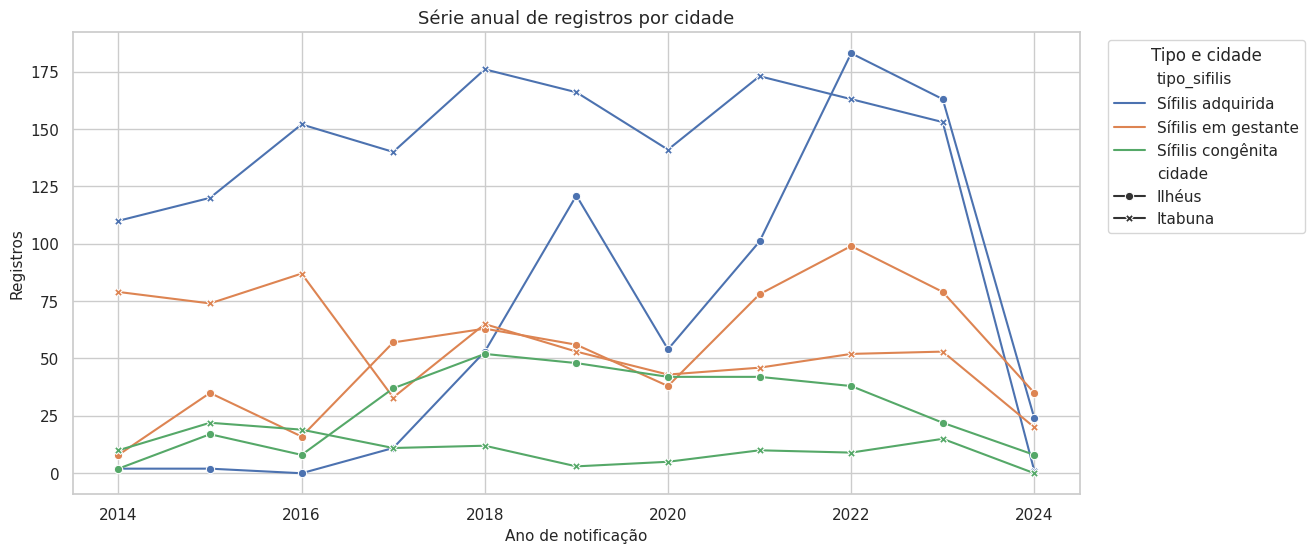

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=cidades_ano_completo, x="ano_notificacao", y="casos", hue="tipo_sifilis", style="cidade", markers=True, dashes=False, ax=ax)
ax.set_title("Série anual de registros por cidade")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Registros")
ax.legend(title="Tipo e cidade", bbox_to_anchor=(1.02, 1), loc="upper left")
salvar_figura(fig, OUTPUT_DIR, "04_serie_anual_cidades.png")
plt.show()

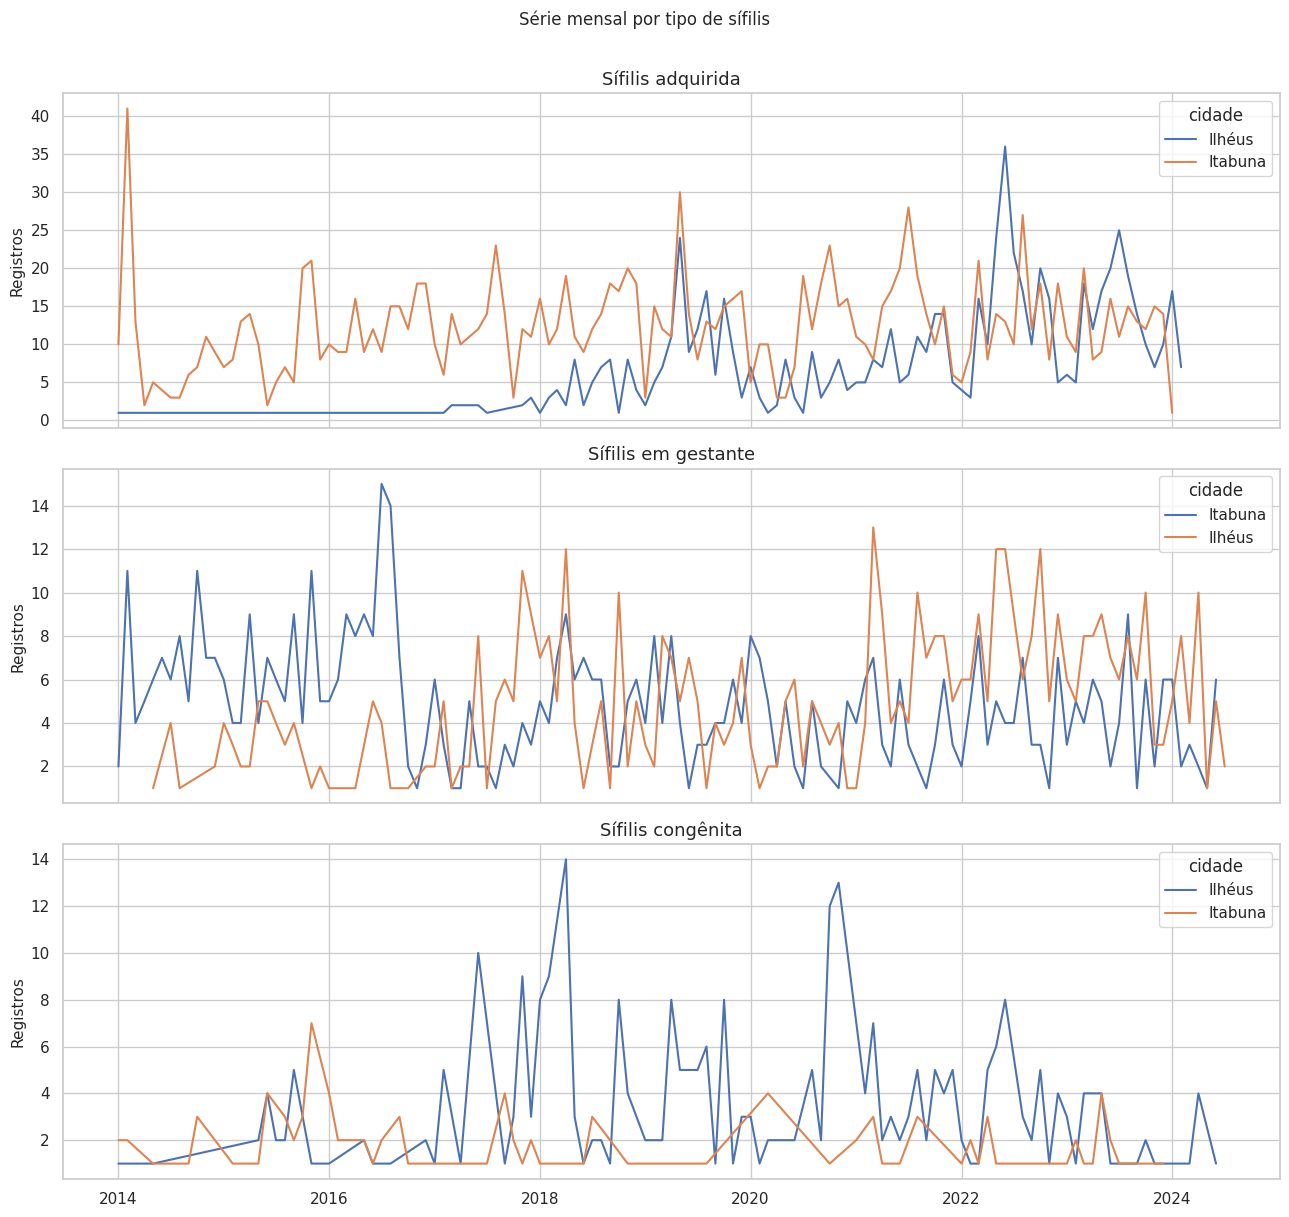

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
for ax, tipo in zip(axes, TIPOS_SIFILIS.values()):
    base = cidades_mes[cidades_mes["tipo_sifilis"] == tipo].sort_values("periodo_data")
    sns.lineplot(data=base, x="periodo_data", y="casos", hue="cidade", ax=ax)
    ax.set_title(tipo)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
fig.suptitle("Série mensal por tipo de sífilis", y=1.01)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "04_serie_mensal_tipos.png")
plt.show()

## Comparação com o total da Bahia

In [5]:
participacao_ano.head()

,ano_notificacao,tipo_sifilis,casos_ilheus_itabuna,casos_bahia,participacao_pct
0,2014,Sífilis adquirida,112,1464,7.650273
1,2014,Sífilis congênita,12,933,1.286174
2,2014,Sífilis em gestante,87,1778,4.893138
3,2015,Sífilis adquirida,122,2206,5.530372
4,2015,Sífilis congênita,39,1185,3.291139


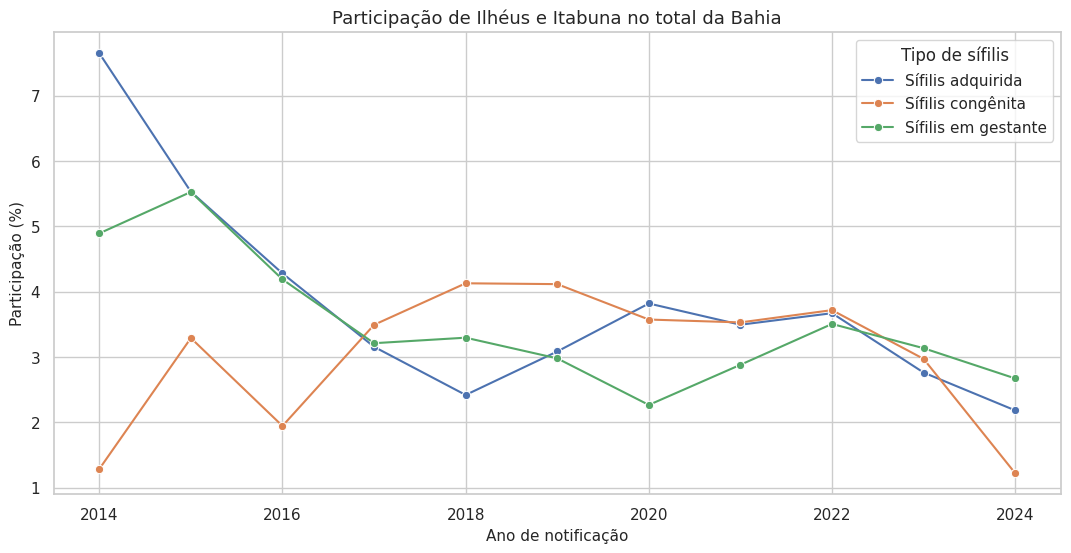

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=participacao_ano, x="ano_notificacao", y="participacao_pct", hue="tipo_sifilis", marker="o", ax=ax)
ax.set_title("Participação de Ilhéus e Itabuna no total da Bahia")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Participação (%)")
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "04_participacao_bahia.png")
plt.show()

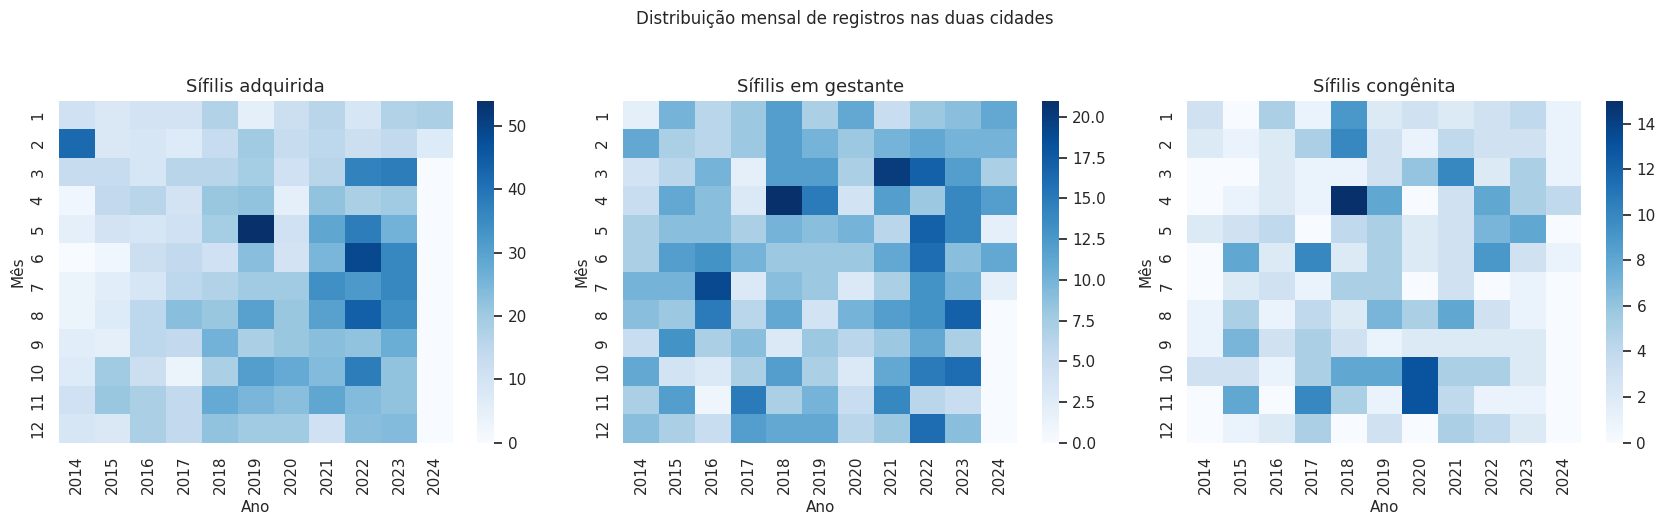

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
for ax, tipo in zip(axes, TIPOS_SIFILIS.values()):
    matriz = (
        cidades_mes[cidades_mes["tipo_sifilis"] == tipo]
        .assign(ano=lambda d: pd.to_datetime(d["periodo_data"]).dt.year, mes=lambda d: pd.to_datetime(d["periodo_data"]).dt.month)
        .pivot_table(index="mes", columns="ano", values="casos", aggfunc="sum", fill_value=0)
    )
    sns.heatmap(matriz, cmap="Blues", ax=ax, cbar=True)
    ax.set_title(tipo)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Mês")
fig.suptitle("Distribuição mensal de registros nas duas cidades", y=1.04)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "04_heatmap_mensal.png")
plt.show()

## Composição dos registros nas cidades

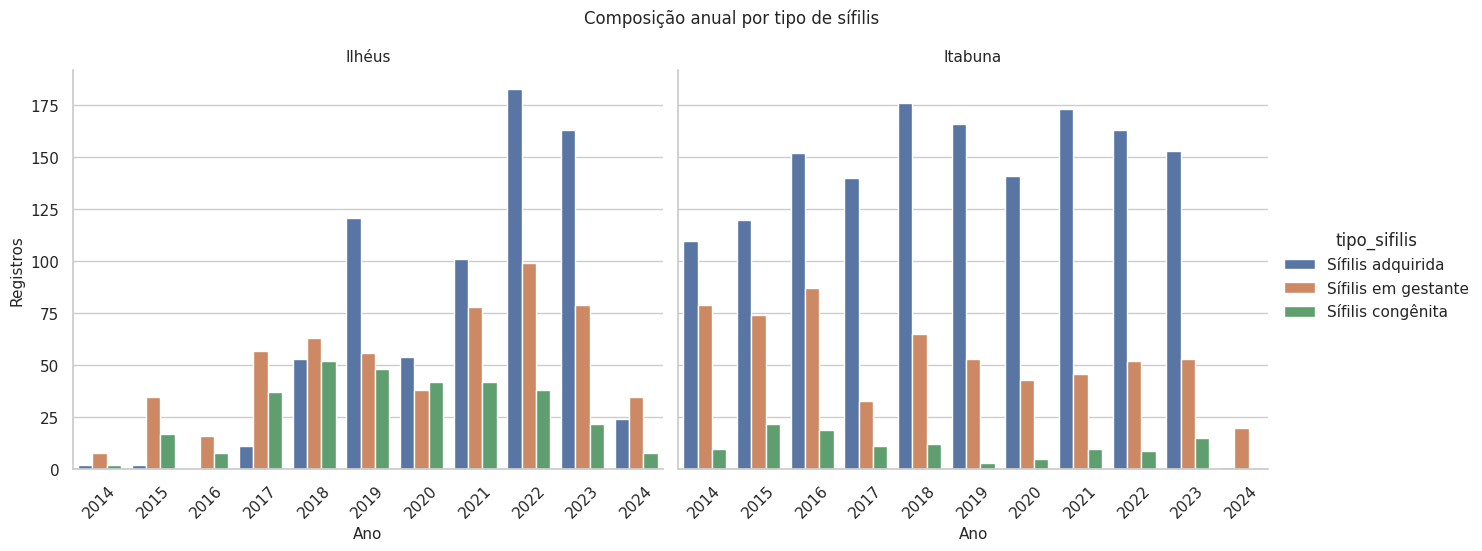

In [8]:
composicao = cidades_ano_completo.copy()
g = sns.catplot(
    data=composicao,
    x="ano_notificacao",
    y="casos",
    hue="tipo_sifilis",
    col="cidade",
    kind="bar",
    height=5,
    aspect=1.3,
)
g.set_axis_labels("Ano", "Registros")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Composição anual por tipo de sífilis", y=1.05)
salvar_figura(g.fig, OUTPUT_DIR, "04_composicao_anual.png")
plt.show()

## Notificações por população total para sífilis adquirida

Este indicador usa população total como denominador e é aplicado apenas à sífilis adquirida. Para sífilis em gestante e sífilis congênita, seriam necessários denominadores específicos.

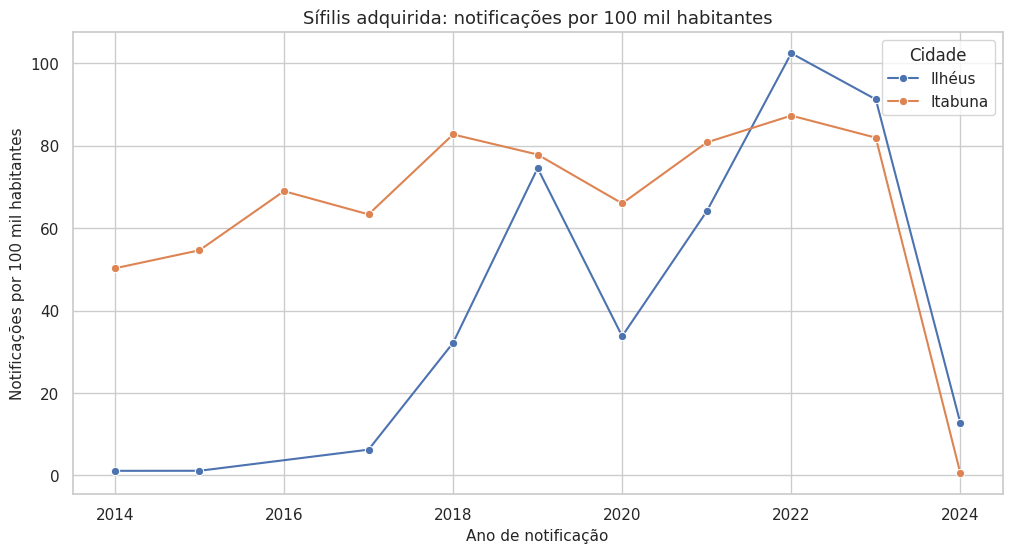

In [9]:
sifa_ano = taxa_tipo[(taxa_tipo["tipo_sifilis"] == "Sífilis adquirida") & (taxa_tipo["localidade"].isin(["Ilhéus", "Itabuna"]))].copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=sifa_ano, x="ano_notificacao", y="taxa_100_mil", hue="localidade", marker="o", ax=ax)
ax.set_title("Sífilis adquirida: notificações por 100 mil habitantes")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Notificações por 100 mil habitantes")
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "04_sifa_100_mil.png")
plt.show()

## Leitura de 2024

In [10]:
comparacao_2024 = comparacao_2024.copy()
comparacao_2024["diferenca_2024_media"] = comparacao_2024["2024"] - comparacao_2024["media_2021_2023"]
comparacao_2024["razao_2024_media"] = comparacao_2024["razao_2024_media_2021_2023"]
comparacao_2024[["cidade", "tipo_sifilis", "2024", "media_2021_2023", "diferenca_2024_media", "razao_2024_media"]]

,cidade,tipo_sifilis,2024,media_2021_2023,diferenca_2024_media,razao_2024_media
0,Ilhéus,Sífilis adquirida,24,149.000000,-125.000000,0.161074
1,Ilhéus,Sífilis congênita,8,34.000000,-26.000000,0.235294
2,Ilhéus,Sífilis em gestante,35,85.333333,-50.333333,0.410156
3,Itabuna,Sífilis adquirida,1,163.000000,-162.000000,0.006135
4,Itabuna,Sífilis congênita,0,11.333333,-11.333333,0.000000
5,Itabuna,Sífilis em gestante,20,50.333333,-30.333333,0.397351


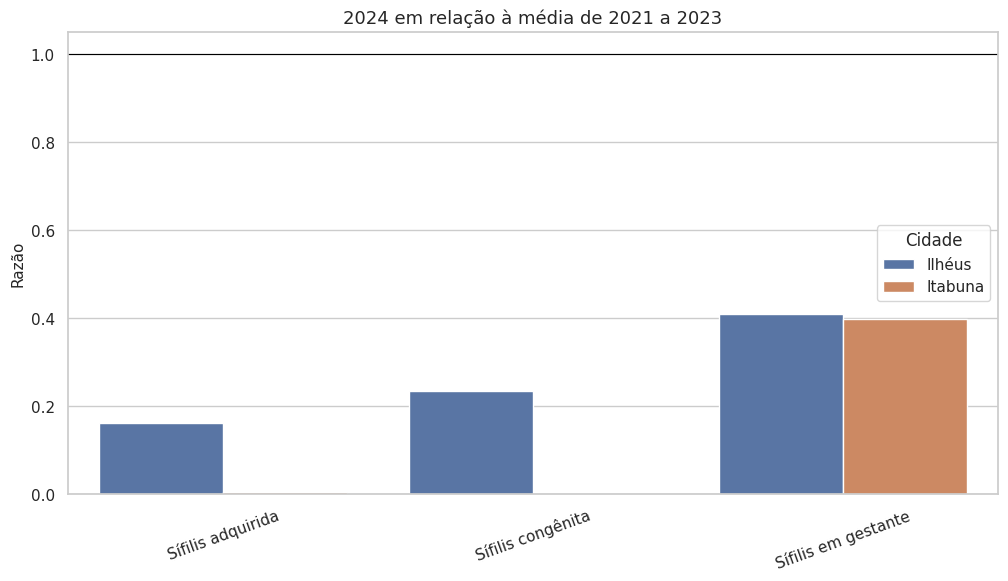

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=comparacao_2024, x="tipo_sifilis", y="razao_2024_media", hue="cidade", ax=ax)
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title("2024 em relação à média de 2021 a 2023")
ax.set_xlabel("")
ax.set_ylabel("Razão")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "04_razao_2024.png")
plt.show()

In [12]:
linha_maior = participacao_ano.sort_values("participacao_pct", ascending=False).iloc[0]
exibir_markdown(f"""
### Observações temporais

A maior participação conjunta de Ilhéus e Itabuna no total da Bahia ocorre em {int(linha_maior['ano_notificacao'])} para {linha_maior['tipo_sifilis']}, com {formatar_percentual(linha_maior['participacao_pct'])}. Em 2024, os totais devem ser interpretados com cautela porque ficam abaixo da média recente em todos os grupos avaliados.
""")


### Observações temporais

A maior participação conjunta de Ilhéus e Itabuna no total da Bahia ocorre em 2014 para Sífilis adquirida, com 7,7%. Em 2024, os totais devem ser interpretados com cautela porque ficam abaixo da média recente em todos os grupos avaliados.


## Bloco complementar — representatividade em relação à Bahia

Este bloco calcula a regra de três entre o total da Bahia e o total de Ilhéus e Itabuna. A comparação usa o município de residência, mantendo a Bahia como referência estadual.

In [13]:
representatividade

,ano_notificacao,casos_ilheus_itabuna,casos_bahia,restante_bahia,participacao_pct
0,2014,211,4175,3964,5.053892
1,2015,270,5363,5093,5.034496
2,2016,282,7398,7116,3.811841
3,2017,289,8959,8670,3.225806
4,2018,421,14897,14476,2.826072
5,2019,447,14199,13752,3.148109
6,2020,323,9993,9670,3.232263
7,2021,450,13616,13166,3.304935
8,2022,544,14994,14450,3.628118
9,2023,485,16894,16409,2.870842


In [14]:
total_bahia_periodo = representatividade["casos_bahia"].sum()
total_cidades_periodo = representatividade["casos_ilheus_itabuna"].sum()
participacao_periodo = total_cidades_periodo / total_bahia_periodo * 100
exibir_markdown(f"""
### Leitura da representatividade

No período analisado, a Bahia soma {formatar_inteiro(total_bahia_periodo)} registros nos três tipos de sífilis. Ilhéus e Itabuna somam {formatar_inteiro(total_cidades_periodo)} registros. Pela regra de três, se a Bahia corresponde a 100%, as duas cidades correspondem a {formatar_percentual(participacao_periodo)} do total estadual.
""")


### Leitura da representatividade

No período analisado, a Bahia soma 114.346 registros nos três tipos de sífilis. Ilhéus e Itabuna somam 3.810 registros. Pela regra de três, se a Bahia corresponde a 100%, as duas cidades correspondem a 3,3% do total estadual.


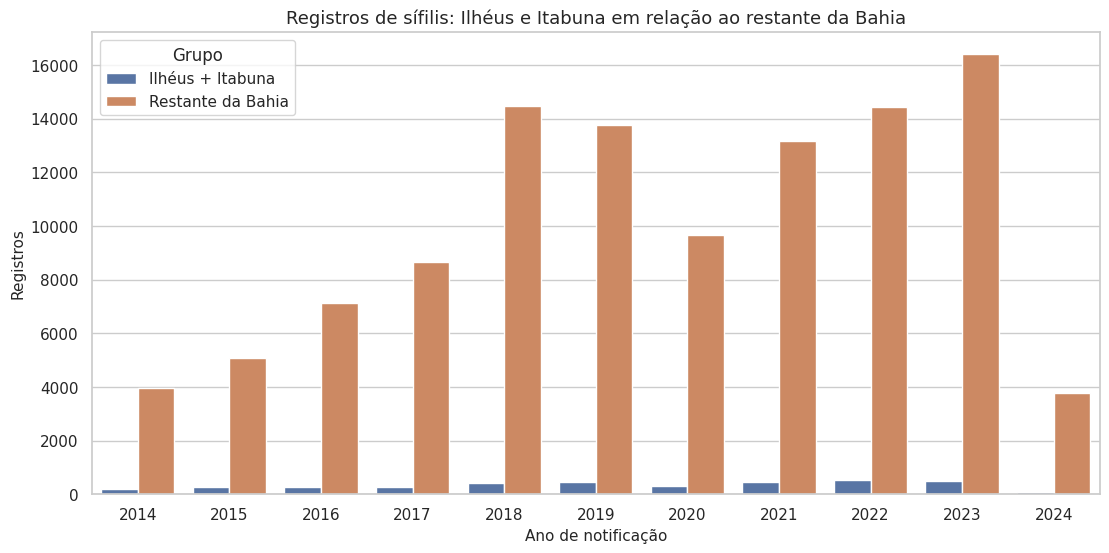

In [15]:
representatividade_plot = representatividade.melt(
    id_vars="ano_notificacao",
    value_vars=["casos_ilheus_itabuna", "restante_bahia"],
    var_name="grupo",
    value_name="casos",
)
representatividade_plot["grupo"] = representatividade_plot["grupo"].map({
    "casos_ilheus_itabuna": "Ilhéus + Itabuna",
    "restante_bahia": "Restante da Bahia",
})
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=representatividade_plot, x="ano_notificacao", y="casos", hue="grupo", ax=ax)
ax.set_title("Registros de sífilis: Ilhéus e Itabuna em relação ao restante da Bahia")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Registros")
ax.legend(title="Grupo")
salvar_figura(fig, OUTPUT_DIR, "04_bloco2_bahia_restante_por_ano.png")
plt.show()

## Bloco complementar — notificações por 100 mil habitantes

A taxa abaixo usa população total como denominador. Para sífilis em gestante e sífilis congênita, a leitura deve ser feita como notificação por população total, não como taxa específica por gestantes ou por nascidos vivos. A população de 2023 usa a população do Censo 2022 como referência, porque a tabela anual de estimativas do IBGE/SIDRA não divulga 2023.

In [16]:
taxa_total.head()

,ano_notificacao,localidade,casos,codigo_sinan,populacao,fonte,url,taxa_100_mil
0,2014,Ilhéus,12,291360,182350,IBGE/SIDRA tabela 6579 - População residente e...,https://apisidra.ibge.gov.br/values/t/6579/n6/...,6.580751
1,2014,Itabuna,199,291480,218925,IBGE/SIDRA tabela 6579 - População residente e...,https://apisidra.ibge.gov.br/values/t/6579/n6/...,90.898710
2,2015,Ilhéus,54,291360,180213,IBGE/SIDRA tabela 6579 - População residente e...,https://apisidra.ibge.gov.br/values/t/6579/n6/...,29.964542
3,2015,Itabuna,216,291480,219680,IBGE/SIDRA tabela 6579 - População residente e...,https://apisidra.ibge.gov.br/values/t/6579/n6/...,98.324836
4,2016,Ilhéus,24,291360,178210,IBGE/SIDRA tabela 6579 - População residente e...,https://apisidra.ibge.gov.br/values/t/6579/n6/...,13.467258


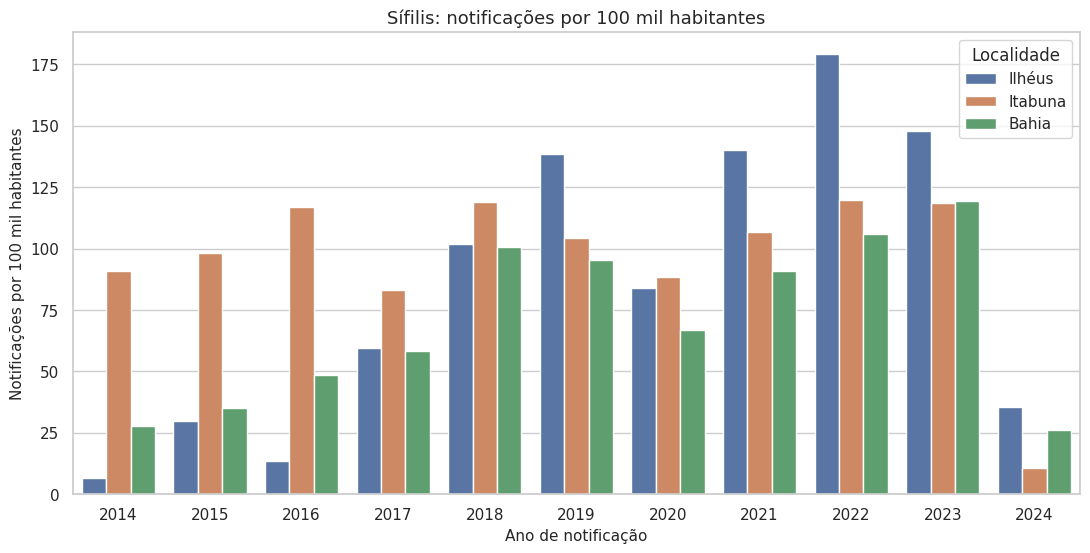

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=taxa_total, x="ano_notificacao", y="taxa_100_mil", hue="localidade", ax=ax)
ax.set_title("Sífilis: notificações por 100 mil habitantes")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Notificações por 100 mil habitantes")
ax.legend(title="Localidade")
salvar_figura(fig, OUTPUT_DIR, "04_bloco3_taxa_100_mil_total.png")
plt.show()

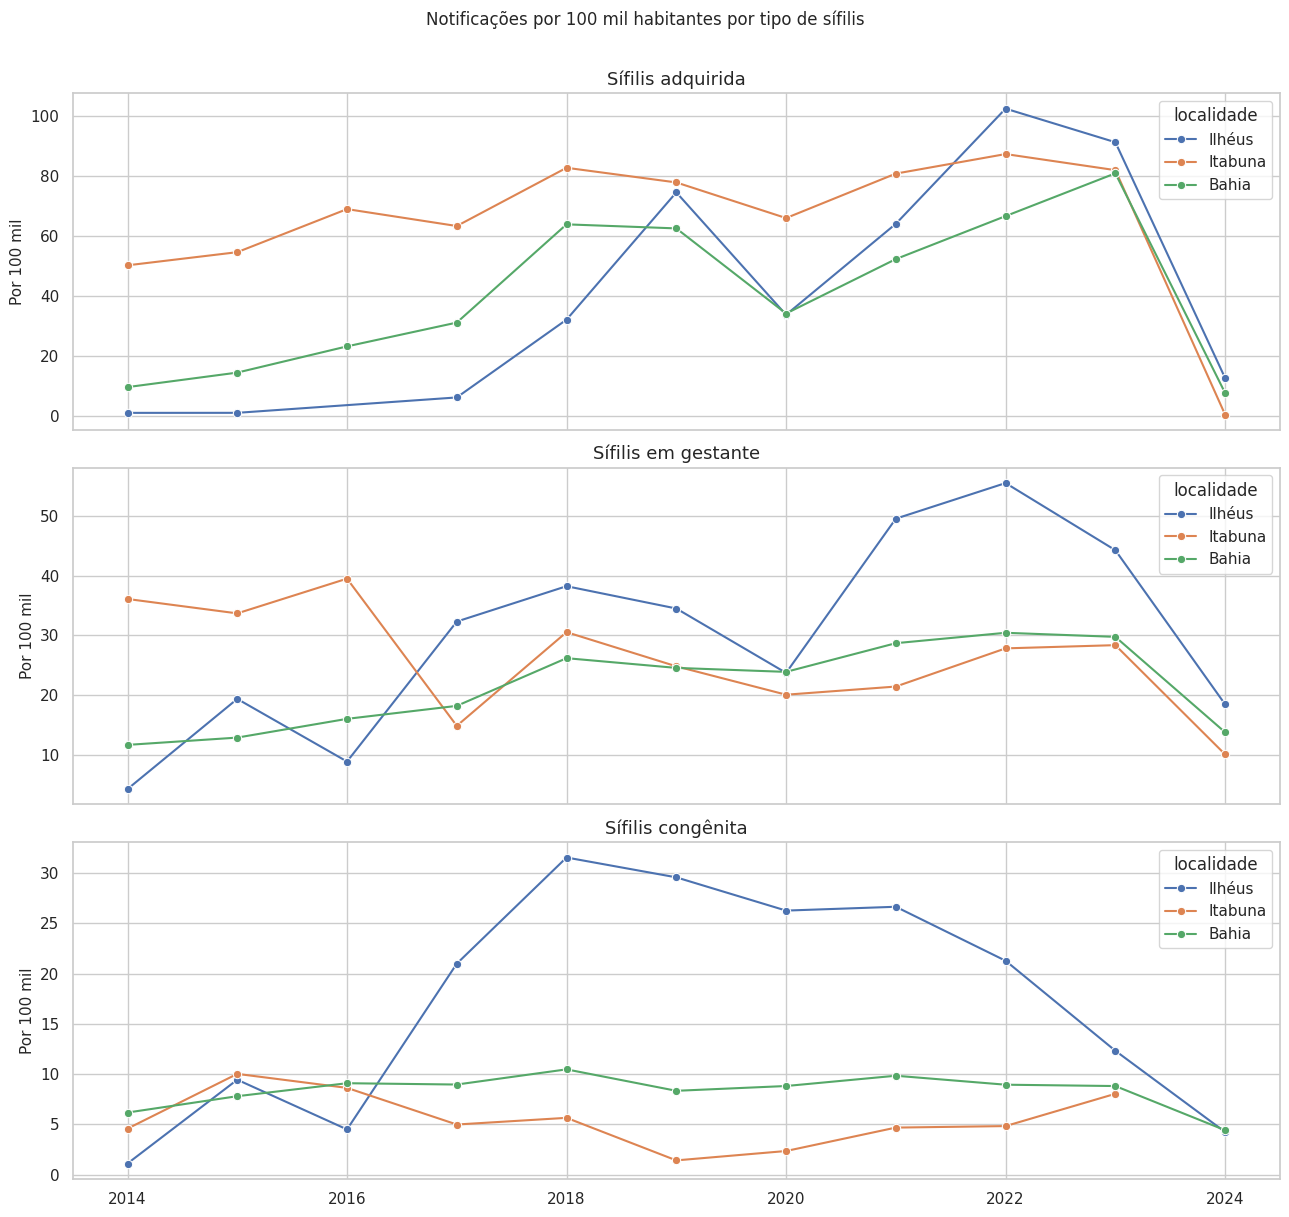

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
for ax, tipo in zip(axes, TIPOS_SIFILIS.values()):
    base = taxa_tipo[taxa_tipo["tipo_sifilis"] == tipo]
    sns.lineplot(data=base, x="ano_notificacao", y="taxa_100_mil", hue="localidade", marker="o", ax=ax)
    ax.set_title(tipo)
    ax.set_xlabel("")
    ax.set_ylabel("Por 100 mil")
fig.suptitle("Notificações por 100 mil habitantes por tipo de sífilis", y=1.01)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "04_bloco3_taxa_100_mil_por_tipo.png")
plt.show()

## Bloco complementar — abrangência geográfica dos atendimentos em Ilhéus e Itabuna

Aqui o recorte muda: em vez de residência em Ilhéus e Itabuna, o filtro usa município de notificação em Ilhéus ou Itabuna. Assim é possível observar de quais municípios de residência vieram os pacientes notificados nessas duas cidades.

In [19]:
import json
import matplotlib as mpl
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

origens_atendimento.head(20)

,cidade_atendimento,codigo_residencia_sinan6,casos,municipio_nome
0,Ilhéus,291360,1519,Ilhéus
1,Ilhéus,291490,93,Itacaré
2,Ilhéus,293270,75,Uruçuca
3,Ilhéus,290630,40,Canavieiras
4,Ilhéus,293250,22,Una
5,Ilhéus,292070,15,Maraú
6,Ilhéus,290580,7,Camamu
7,Ilhéus,292090,5,Mascote
8,Ilhéus,290240,4,Aurelino Leal
9,Ilhéus,291480,4,Itabuna


In [20]:
for cidade in ["Ilhéus", "Itabuna"]:
    tabela = origens_atendimento[origens_atendimento["cidade_atendimento"] == cidade].head(12)
    display(tabela[["cidade_atendimento", "municipio_nome", "casos"]])

,cidade_atendimento,municipio_nome,casos
0,Ilhéus,Ilhéus,1519
1,Ilhéus,Itacaré,93
2,Ilhéus,Uruçuca,75
3,Ilhéus,Canavieiras,40
4,Ilhéus,Una,22
5,Ilhéus,Maraú,15
6,Ilhéus,Camamu,7
7,Ilhéus,Mascote,5
8,Ilhéus,Aurelino Leal,4
9,Ilhéus,Itabuna,4


,cidade_atendimento,municipio_nome,casos
25,Itabuna,Itabuna,2186
26,Itabuna,Buerarema,55
27,Itabuna,Ilhéus,48
28,Itabuna,Itajuípe,44
29,Itabuna,Ubaitaba,37
30,Itabuna,Ibicaraí,36
31,Itabuna,Camacan,33
32,Itabuna,Coaraci,31
33,Itabuna,Aurelino Leal,28
34,Itabuna,Camamu,28


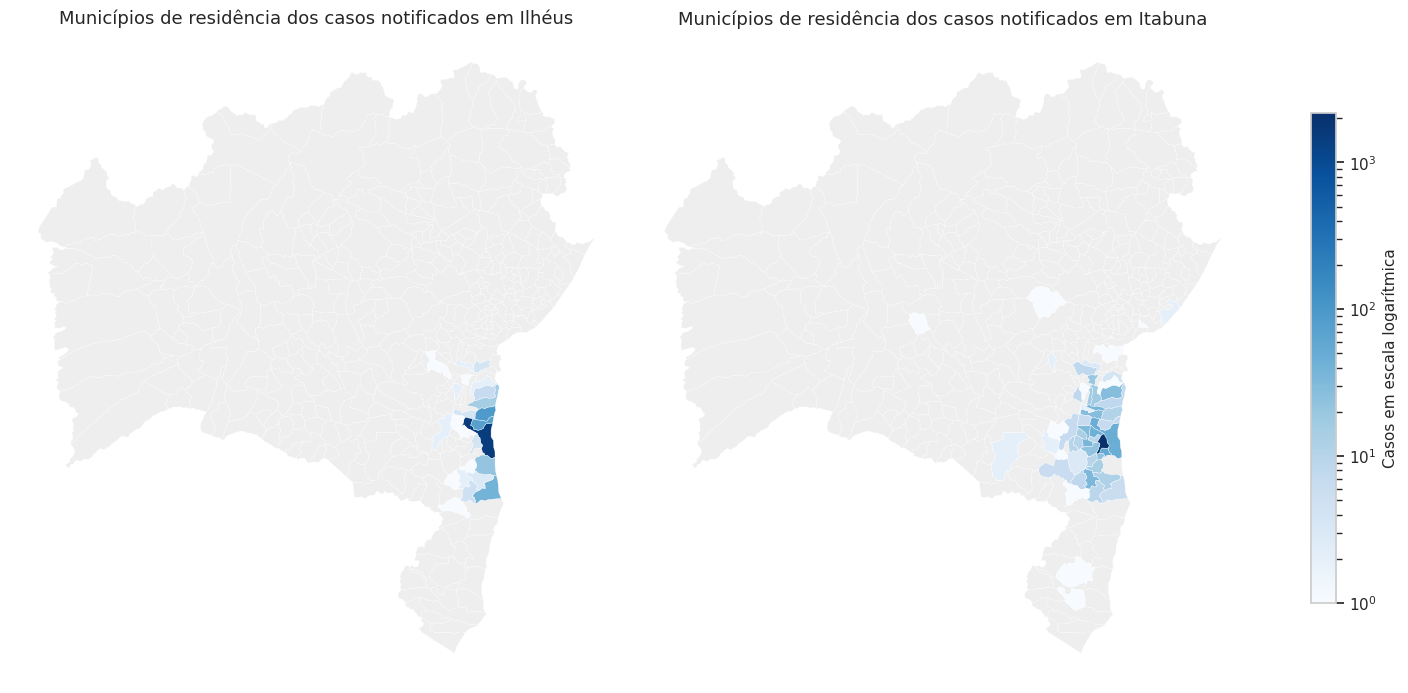

In [21]:
def _poligonos_feature(feature):
    geom = feature.get("geometry") or {}
    tipo = geom.get("type")
    coords = geom.get("coordinates") or []
    if tipo == "Polygon":
        for ring in coords[:1]:
            yield ring
    elif tipo == "MultiPolygon":
        for polygon in coords:
            if polygon:
                yield polygon[0]

with open(geojson_path, encoding="utf-8") as handle:
    malha = json.load(handle)

contagens = {
    cidade: dict(zip(grupo["codigo_residencia_sinan6"].astype(str), grupo["casos"]))
    for cidade, grupo in origens_atendimento.groupby("cidade_atendimento")
}
max_casos = max([max(valores.values()) for valores in contagens.values() if valores] + [1])
norm = mpl.colors.LogNorm(vmin=1, vmax=max_casos)
cmap = mpl.cm.Blues

fig, axes = plt.subplots(1, 2, figsize=(14, 9), constrained_layout=True)
for ax, cidade in zip(axes, ["Ilhéus", "Itabuna"]):
    patches_fundo = []
    patches_casos = []
    valores = []
    cidade_counts = contagens.get(cidade, {})
    for feature in malha["features"]:
        codigo = str(feature["properties"].get("codigo_sinan6"))
        for ring in _poligonos_feature(feature):
            poly = MplPolygon(ring, closed=True)
            caso = cidade_counts.get(codigo, 0)
            if caso > 0:
                patches_casos.append(poly)
                valores.append(caso)
            else:
                patches_fundo.append(poly)
    if patches_fundo:
        ax.add_collection(PatchCollection(patches_fundo, facecolor="#eeeeee", edgecolor="#ffffff", linewidth=0.2))
    if patches_casos:
        colecao = PatchCollection(patches_casos, cmap=cmap, norm=norm, edgecolor="#ffffff", linewidth=0.25)
        colecao.set_array(np.array(valores))
        ax.add_collection(colecao)
    ax.autoscale()
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"Municípios de residência dos casos notificados em {cidade}")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.55, label="Casos em escala logarítmica")
salvar_figura(fig, OUTPUT_DIR, "04_bloco4_mapa_origem_atendimento.png")
plt.show()

In [22]:
municipios_distintos = origens_atendimento.groupby("cidade_atendimento")["codigo_residencia_sinan6"].nunique()
mais_amplo = municipios_distintos.sort_values(ascending=False).index[0]
exibir_markdown(f"""
### Observações sobre abrangência geográfica

Os registros notificados em Ilhéus e Itabuna incluem pessoas residentes em diferentes municípios da Bahia. No recorte analisado, {mais_amplo} apresenta a maior quantidade de municípios de residência distintos entre as duas cidades de atendimento. O mapa usa o município de residência e não deve ser lido como local de transmissão.
""")


### Observações sobre abrangência geográfica

Os registros notificados em Ilhéus e Itabuna incluem pessoas residentes em diferentes municípios da Bahia. No recorte analisado, Itabuna apresenta a maior quantidade de municípios de residência distintos entre as duas cidades de atendimento. O mapa usa o município de residência e não deve ser lido como local de transmissão.
